# About

This notebook is for machine learning related experimentation.

## Imports

In [3]:
import pandas as pd
from src.preprocessing.validator import validate_schema, validate_rules
from src.preprocessing.result import ValidationResult
from src.core.config import load_validation_schema, load_validation_rules, load_cleaning_configuration
from src.ml.random_forest import RandomForest
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from src.preprocessing.cleaning import clean
from src.dataset.loader import load_cicids2017_dataset
from pathlib import Path
from src.preprocessing.preprocessing import PreprocessingPipeline, initial_cleanup

# Loading Dataset

In [4]:
dataset_dir = '../dataset'

df = load_cicids2017_dataset(dataset_dir)

## Validation and Cleaning

In [5]:
sp = Path('../config/preprocessing/validation_shema.yaml')
schema_cfg = load_validation_schema(sp)

rp = Path('../config/preprocessing/validation_rules.yaml')
rules_cfg = load_validation_rules(rp)

cleaning_path = Path('../config/preprocessing/cleaning.yaml')
cleaning_cfg = load_cleaning_configuration(cleaning_path)

preprocess = PreprocessingPipeline(schema_cfg, rules_cfg, cleaning_cfg)

df = initial_cleanup(df)

preprocess.validate(df)
df = preprocess.clean(df)

preprocess.validate(df)
df = preprocess.clean(df)

preprocess.validate(df)

print(preprocess.validation_result[f'validation_result_{len(preprocess.validation_result)}'])

Validation Result
----------------------
Repairable: 0
Non-repairable: 0
NaN*: 0
Inf*: 0
Negative*: 0
Out Of range*: 0
Rule violators: {'R001': np.int64(0), 'R002': np.int64(0), 'R003': np.int64(0), 'R004': np.int64(0), 'R005': np.int64(0), 'R006': np.int64(0), 'R007': np.int64(0), 'R008': np.int64(0), 'R009': np.int64(0), 'R010': np.int64(0), 'R011': np.int64(0), 'R012': np.int64(0), 'R013': np.int64(0), 'R014': np.int64(0), 'R015': np.int64(0), 'R016': np.int64(0), 'R017': np.int64(0), 'R018': np.int64(0), 'R019': np.int64(0)}----------------------
NOTE: those marked with * are showing individual cell value count, not row.
Just so you know, a single row can have multiple NaN, Inf, Negative etc. values.


In [7]:
cols_to_drop = [
    'Bwd PSH Flags',
    'Bwd URG Flags',
    'Fwd Avg Bytes/Bulk',
    'Fwd Avg Packets/Bulk',
    'Fwd Avg Bulk Rate',
    'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk',
    'Bwd Avg Bulk Rate',
    "Fwd Header Length.1"
]

df.drop(columns=cols_to_drop, inplace=True)

## Machine Learning

In [8]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["Label"])
x = df.drop(columns='Label')

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
model = RandomForest()
model.fit(x_train, y_train)

In [10]:
out_data_path = Path('../out/data/')
out_data_path.mkdir(exist_ok=True, parents=True)

importance_df = (
    pd.DataFrame({
        "Feature": x.columns,
        "Importance": model.model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

importance_df.to_csv(
    Path(out_data_path, "Feature Importance RF.csv"),
    index=False
)

print(importance_df)

                    Feature    Importance
38       Packet Length Mean  4.987274e-02
60     min_seg_size_forward  4.937062e-02
58  Init_Win_bytes_backward  4.615727e-02
44           PSH Flag Count  4.611838e-02
14             Flow Bytes/s  4.574128e-02
..                      ...           ...
64               Active Min  5.063648e-04
47           CWE Flag Count  2.491584e-06
31            Fwd URG Flags  2.409807e-06
43           RST Flag Count  6.337832e-08
48           ECE Flag Count  0.000000e+00

[69 rows x 2 columns]


Accuracy: 1.00

Classification Report:
                   precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    106226
            DDoS       0.88      0.78      0.82       376
        PortScan       1.00      0.84      0.91        19
             Bot       1.00      0.94      0.97        16
    Infiltration       1.00      1.00      1.00      1732
     FTP-Patator       1.00      1.00      1.00       225
     SSH-Patator       1.00      1.00      1.00       635
   DoS slowloris       1.00      1.00      1.00      1173
DoS Slowhttptest       1.00      0.67      0.80         3
        DoS Hulk       0.99      0.99      0.99     18082
   DoS GoldenEye       1.00      1.00      1.00       637

        accuracy                           1.00    129124
       macro avg       0.99      0.93      0.95    129124
    weighted avg       1.00      1.00      1.00    129124



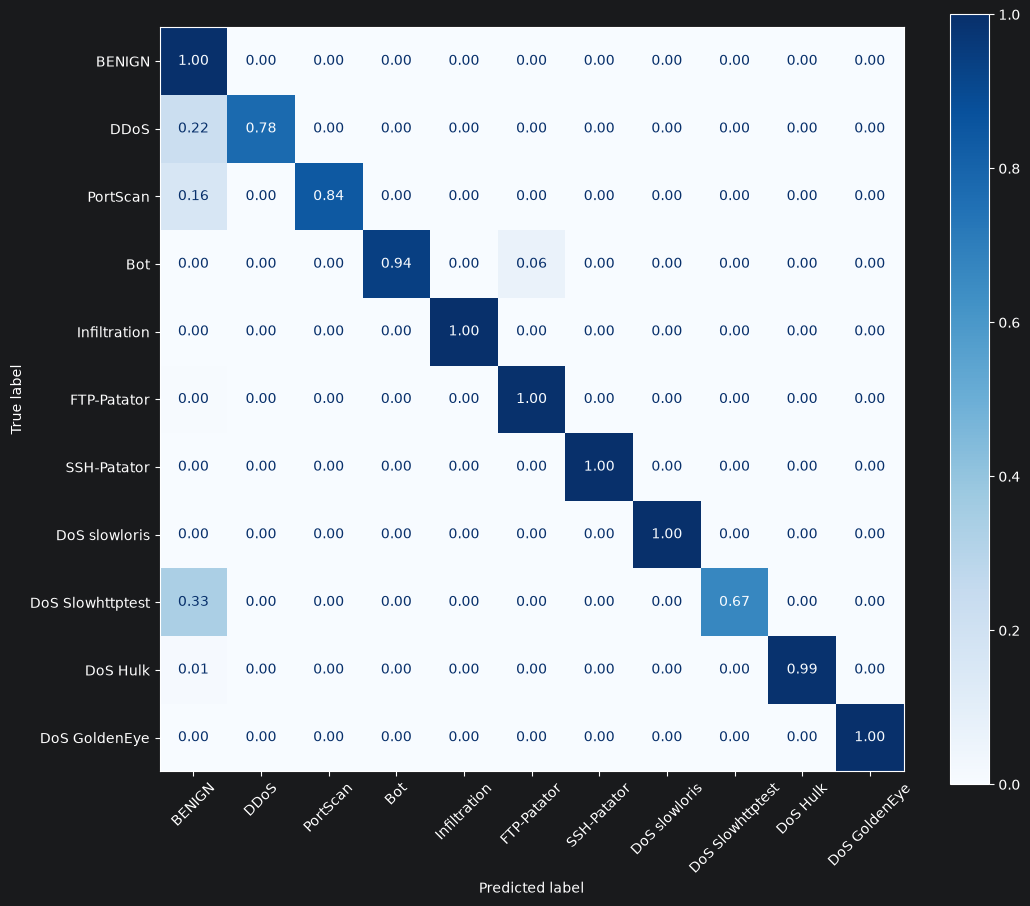

In [11]:
plt_path = Path('../out/plots/')
plt_path.mkdir(exist_ok=True, parents=True)

y_pred = model.predict(x_test)
labels = df['Label'].values.unique()
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=labels)
cm = confusion_matrix(y_test, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f', xticks_rotation=45)

print(f"Accuracy: {accuracy:.2f}")
print(f"\nClassification Report:\n {classification_rep}")
plt.savefig(Path(plt_path, 'RF - ConfusionMatrix.png'))
plt.show()

In [12]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(train_acc)
print(test_acc)

0.9993049290020795
0.9960193302561878


In [13]:
print("Training Report")
print(classification_report(y_train, train_pred, target_names=labels))

print("Test Report")
print(classification_report(y_test, test_pred, target_names=labels))

Training Report
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    424905
            DDoS       1.00      1.00      1.00      1502
        PortScan       1.00      0.97      0.99        74
             Bot       1.00      1.00      1.00        65
    Infiltration       1.00      1.00      1.00      6930
     FTP-Patator       1.00      1.00      1.00       898
     SSH-Patator       1.00      1.00      1.00      2542
   DoS slowloris       1.00      1.00      1.00      4691
DoS Slowhttptest       1.00      1.00      1.00        11
        DoS Hulk       1.00      1.00      1.00     72326
   DoS GoldenEye       1.00      1.00      1.00      2550

        accuracy                           1.00    516494
       macro avg       1.00      1.00      1.00    516494
    weighted avg       1.00      1.00      1.00    516494

Test Report
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00   

From above, it does not seem like the model is overfitting, but rather that we don't have enough data, but the original CICIDS2017 dataset had enough. The problem likely occurred in cleaning. It may have been too aggressive, will need to inspect that.